 Dataset Info:
Shape of dataset: (14999, 10)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Missing Values:
 satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company   

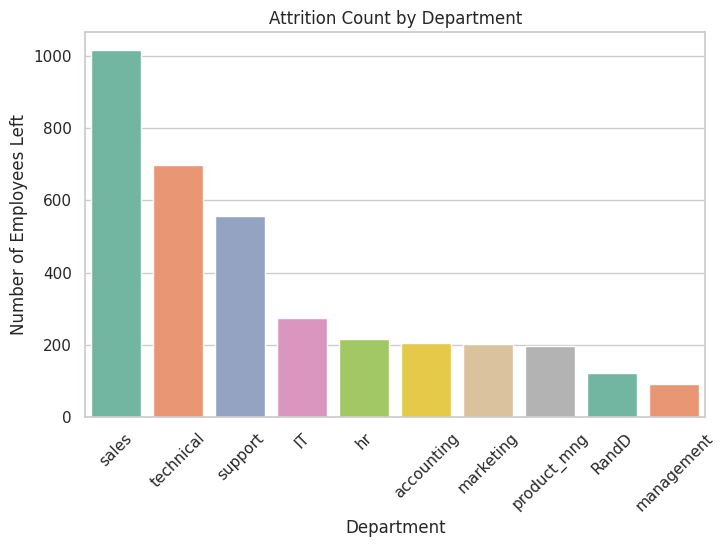


3️ Attrition Rate for employees with <3 projects: 65.62%
   Overall Attrition Rate: 23.81%


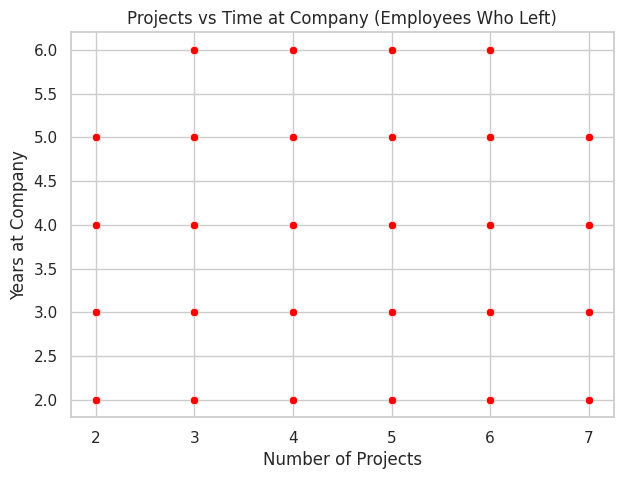

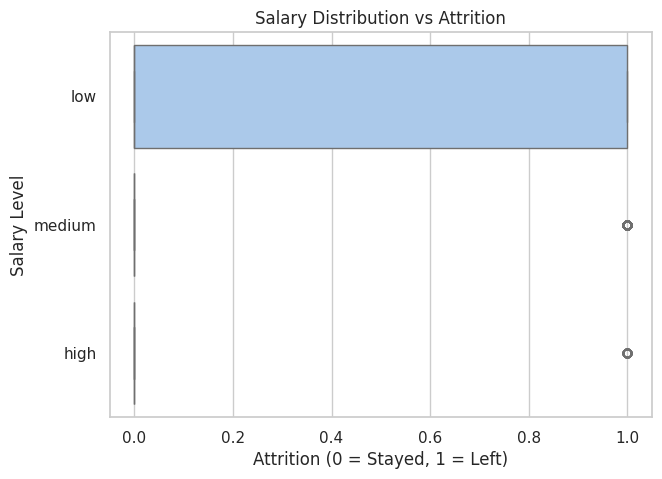

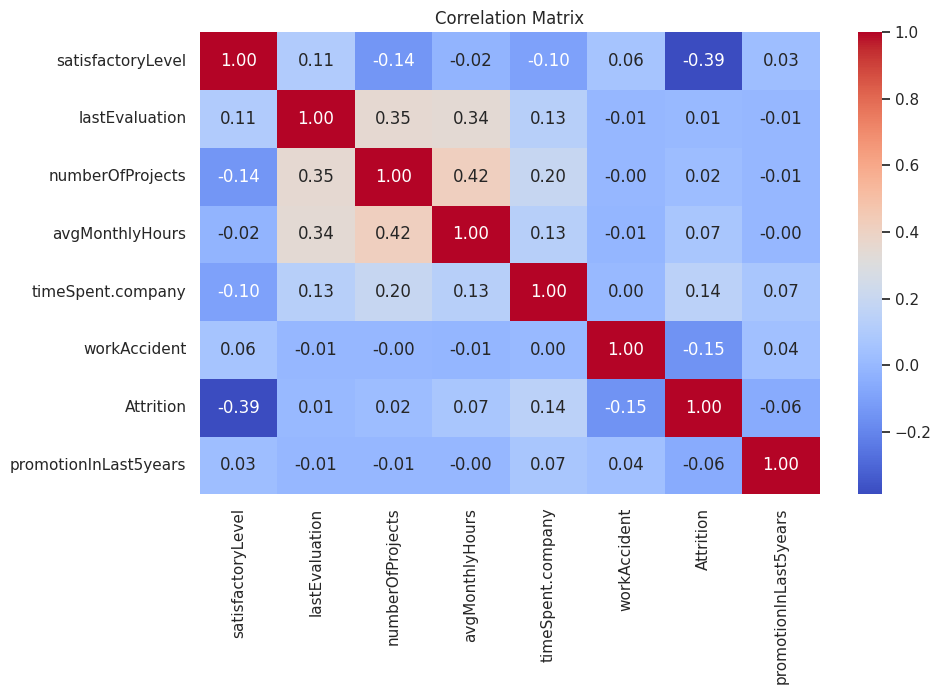


 Summary of Key Insights:
 Total Employees: 14999, Left: 3571
 Departments with highest attrition:
 dept
sales          1014
technical       697
support         555
IT              273
hr              215
accounting      204
marketing       203
product_mng     198
RandD           121
management       91
Name: count, dtype: int64
 Employees with <3 projects had an attrition rate of 65.62%
 Scatterplot shows employees who left often worked on fewer projects and stayed less time.
 Boxplot indicates lower salary may be linked to higher attrition.


In [2]:
# HR Analytics Project - SimpleYard
# Complete One-Block Code for Google Colab

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
%matplotlib inline

# Step 2: Load dataset
df = pd.read_csv('/content/employe.csv')  # Make sure you've uploaded the file in Colab

# Step 3: Basic info
print(" Dataset Info:")
print("Shape of dataset:", df.shape)
print("\nColumn Info:")
df.info()
print("\nMissing Values:\n", df.isnull().sum())

# Step 4: Rename 'left' column to 'Attrition' for clarity
df.rename(columns={'left': 'Attrition'}, inplace=True)

# Step 5: Summary stats
print("\n Dataset Summary:")
print(df.describe())

# Step 6: Q1 - Total employees and how many left
total_employees = df.shape[0]
employees_left = df['Attrition'].sum()
print(f"\n1️ Total Employees: {total_employees}")
print(f"   Employees Who Left: {employees_left}")

# Step 7: Q2 - Department-wise attrition
dept_attr = df[df['Attrition'] == 1]['dept'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=dept_attr.index, y=dept_attr.values, hue=dept_attr.index, palette='Set2', legend=False)
plt.title("Attrition Count by Department")
plt.ylabel("Number of Employees Left")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.show()

# Step 8: Q3 - <3 projects and attrition rate
low_projects = df[df['numberOfProjects'] < 3]
low_proj_attrition = low_projects['Attrition'].mean() * 100
overall_attrition = df['Attrition'].mean() * 100
print(f"\n3️ Attrition Rate for employees with <3 projects: {low_proj_attrition:.2f}%")
print(f"   Overall Attrition Rate: {overall_attrition:.2f}%")

# Step 9: Q4 - Number of projects vs time at company (only for employees who left)
left_df = df[df['Attrition'] == 1]
plt.figure(figsize=(7, 5))
sns.scatterplot(data=left_df, x='numberOfProjects', y='timeSpent.company', color='red')
plt.title("Projects vs Time at Company (Employees Who Left)")
plt.xlabel("Number of Projects")
plt.ylabel("Years at Company")
plt.show()

# Step 10: Q5 - Salary vs Attrition
plt.figure(figsize=(7, 5))
sns.boxplot(x='Attrition', y='salary', data=df, hue='salary', palette='pastel', dodge=False)
plt.title("Salary Distribution vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Salary Level")
plt.show()

# Step 11: Correlation Matrix
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# Step 12: Summary of Insights
print("\n Summary of Key Insights:")
print(f" Total Employees: {total_employees}, Left: {employees_left}")
print(" Departments with highest attrition:\n", dept_attr)
print(f" Employees with <3 projects had an attrition rate of {low_proj_attrition:.2f}%")
print(" Scatterplot shows employees who left often worked on fewer projects and stayed less time.")
print(" Boxplot indicates lower salary may be linked to higher attrition.")
